# Parallel raster computations with Dask

Speed up raster band-math by letting `rioxarray` back the arrays with Dask chunks, so NDVI is computed lazily and in parallel across threads. Compare a serial computation with a chunked, parallel one, inspect the Dask task graph, and write the result to `../outputs/`. Bands are read from `../data/sentinel2/`.

## 1. Chunked (Dask-backed) arrays

In [1]:
import rioxarray
red = rioxarray.open_rasterio("../data/sentinel2/red.tif", chunks=(1, 4000, 4000))
red

/Users/dhruvkapri/Desktop/Developer/geospatial-python/.venv/lib/python3.12/site-packages/rioxarray/_io.py:944: FutureWarning: Supplying chunks as dimension-order tuples is deprecated. It will raise an error in the future. Instead use a dict with dimension names as keys.
  return result.chunk(chunks, name_prefix=name_prefix, token=token)


<xarray.DataArray (band: 1, y: 10980, x: 10980)> Size: 241MB
dask.array<open_rasterio-b7820380ae60173290444bf99aede722<this-array>, shape=(1, 10980, 10980), dtype=uint16, chunksize=(1, 4000, 4000), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 88kB 4.1e+06 4.1e+06 4.1e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 88kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0

### Chunk sizes matter

A GeoTIFF stored in tiles is read most efficiently when the Dask chunks line up with the file's internal tiling. Check the on-disk block shape:

In [2]:
import rasterio
with rasterio.open("../data/sentinel2/red.tif") as r:
    if r.is_tiled:
        print(f"Chunk size: {r.block_shapes}")

Chunk size: [(1024, 1024)]


In [3]:
red = rioxarray.open_rasterio("../data/sentinel2/red.tif", chunks=(1, 6144, 6144))
red

/Users/dhruvkapri/Desktop/Developer/geospatial-python/.venv/lib/python3.12/site-packages/rioxarray/_io.py:944: FutureWarning: Supplying chunks as dimension-order tuples is deprecated. It will raise an error in the future. Instead use a dict with dimension names as keys.
  return result.chunk(chunks, name_prefix=name_prefix, token=token)


<xarray.DataArray (band: 1, y: 10980, x: 10980)> Size: 241MB
dask.array<open_rasterio-4543657c111971142a33080bc1d40a75<this-array>, shape=(1, 10980, 10980), dtype=uint16, chunksize=(1, 6144, 6144), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 88kB 4.1e+06 4.1e+06 4.1e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 88kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0

In [4]:
red = rioxarray.open_rasterio("../data/sentinel2/red.tif", chunks="auto")
red

<xarray.DataArray (band: 1, y: 10980, x: 10980)> Size: 241MB
dask.array<open_rasterio-d13ff05df9edbff816a43ea7175f4de8<this-array>, shape=(1, 10980, 10980), dtype=uint16, chunksize=(1, 8192, 8192), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 88kB 4.1e+06 4.1e+06 4.1e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 88kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0

## 2. Serial vs. parallel NDVI

First the serial version, with the bands loaded eagerly into memory:

In [5]:
red = rioxarray.open_rasterio("../data/sentinel2/red.tif", masked=True)
nir = rioxarray.open_rasterio("../data/sentinel2/nir.tif", masked=True)

In [6]:
%%time
ndvi = (nir - red) / (nir + red)

CPU times: user 7.13 s, sys: 4.27 s, total: 11.4 s
Wall time: 13.9 s


Now the Dask-backed version: `lock=False` allows concurrent reads and `chunks` splits the work into tiles that run in parallel.

In [7]:
red_dask = rioxarray.open_rasterio("../data/sentinel2/red.tif", masked=True, lock=False, chunks=(1, 6144, 6144))
nir_dask = rioxarray.open_rasterio("../data/sentinel2/nir.tif", masked=True, lock=False, chunks=(1, 6144, 6144))

/Users/dhruvkapri/Desktop/Developer/geospatial-python/.venv/lib/python3.12/site-packages/rioxarray/_io.py:944: FutureWarning: Supplying chunks as dimension-order tuples is deprecated. It will raise an error in the future. Instead use a dict with dimension names as keys.
  return result.chunk(chunks, name_prefix=name_prefix, token=token)
/Users/dhruvkapri/Desktop/Developer/geospatial-python/.venv/lib/python3.12/site-packages/rioxarray/_io.py:944: FutureWarning: Supplying chunks as dimension-order tuples is deprecated. It will raise an error in the future. Instead use a dict with dimension names as keys.
  return result.chunk(chunks, name_prefix=name_prefix, token=token)


In [8]:
%%time
ndvi_dask = (nir_dask - red_dask) / (nir_dask + red_dask)

CPU times: user 9.37 ms, sys: 8.16 ms, total: 17.5 ms
Wall time: 28.6 ms


Inspect the lazy Dask task graph:

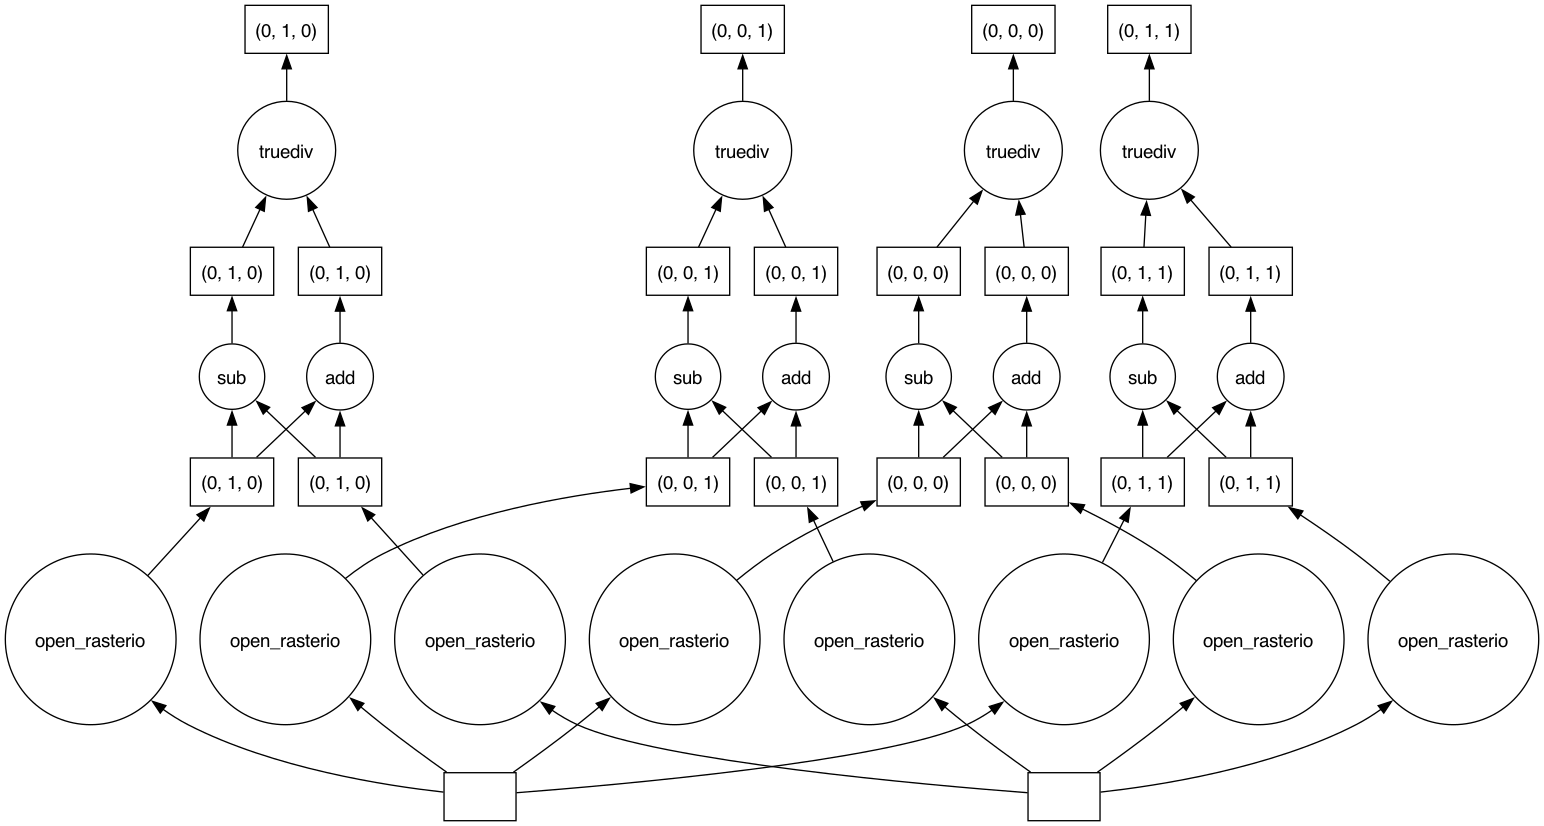

In [9]:
import dask
dask.visualize(ndvi_dask)

Trigger the computation in parallel with `persist` (keeps the result in memory as a Dask array):

In [10]:
%%time
ndvi_dask = ndvi_dask.persist(scheduler="threads", num_workers=4)

CPU times: user 4.18 s, sys: 2.57 s, total: 6.75 s
Wall time: 2.95 s


## 3. Save the result

In [11]:
from threading import Lock
ndvi_dask.rio.to_raster("../outputs/ndvi.tif", tiled=True, lock=Lock())